In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
# Download market data
tickers = ["^GSPC", "^VIX", "^TNX"]

data = yf.download(tickers, period="5y")["Close"]
data = data.dropna()

# Rename columns
data = data.rename(columns={
    "^GSPC": "S&P 500",
    "^VIX": "VIX",
    "^TNX": "US 10Y Yield"
})

data.head()

C:\Users\mathi\AppData\Local\Temp\ipykernel_46560\4034182488.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period="5y")["Close"]
[*********************100%***********************]  3 of 3 completed


Ticker,S&P 500,US 10Y Yield,VIX
Date,,,
2021-04-05,4077.909912,1.720,17.910000
2021-04-06,4073.939941,1.656,18.120001
2021-04-07,4079.949951,1.653,17.160000
2021-04-08,4097.169922,1.632,16.950001
2021-04-09,4128.799805,1.666,16.690001


We download key market indicators:
- S&P 500 for equity market performance
- VIX as a proxy for market volatility
- US 10Y yield for interest rates

In [19]:
normalized_data = data / data.iloc[0] * 100

The data is normalized to a base value of 100 at the initial date.

This allows for a direct comparison of relative performance across assets.

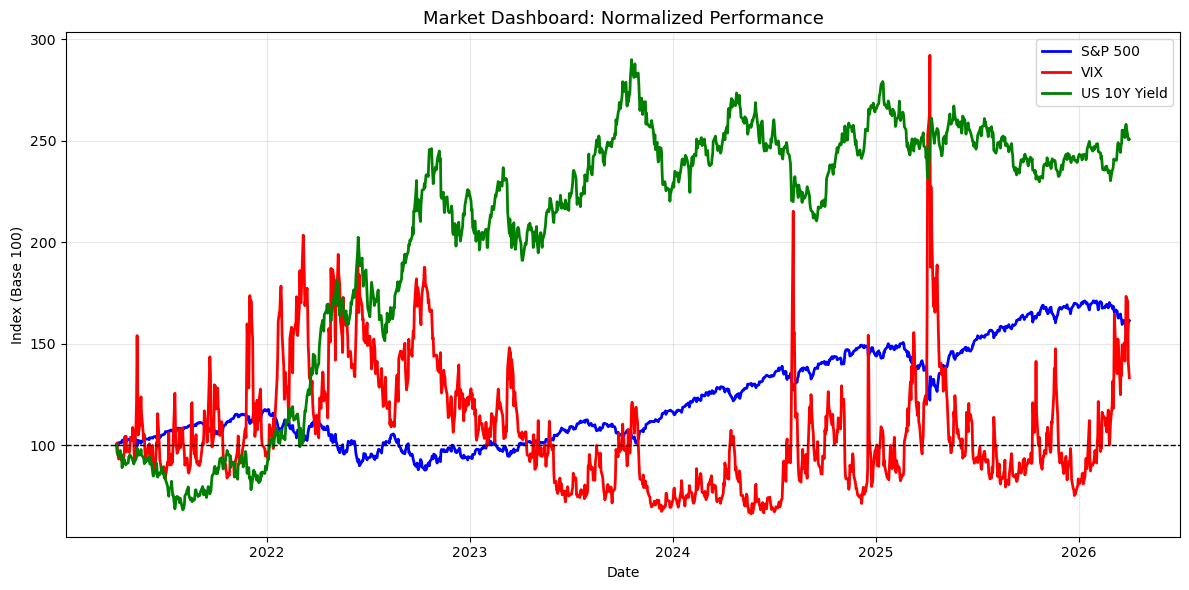

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(normalized_data.index, normalized_data["S&P 500"], color="blue", linewidth=2, label="S&P 500")
plt.plot(normalized_data.index, normalized_data["VIX"], color="red", linewidth=2, label="VIX")
plt.plot(normalized_data.index, normalized_data["US 10Y Yield"], color="green", linewidth=2, label="US 10Y Yield")
plt.axhline(y=100, color="black", linestyle="--", linewidth=1)
plt.title("Market Dashboard: Normalized Performance", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Index (Base 100)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The normalized chart rebases all series to 100 at the starting date.

This makes it possible to compare relative performance across market indicators that have very different original levels.

We typically observe smoother long-term movements for equity indices, sharper fluctuations for volatility, and more moderate changes in bond yields.

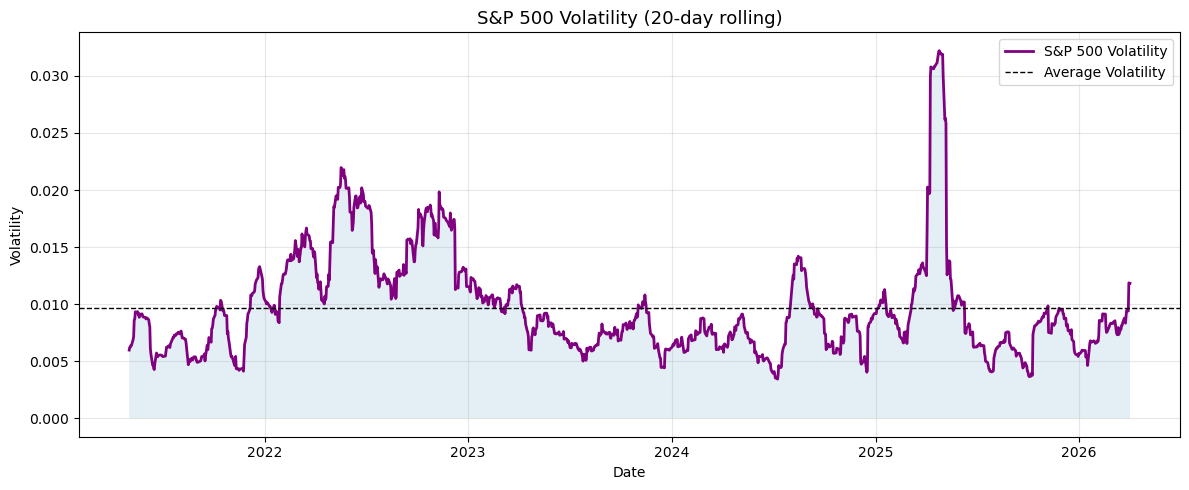

In [25]:
returns = data.pct_change().dropna()
rolling_vol = returns["S&P 500"].rolling(20).std()

plt.figure(figsize=(12, 5))
plt.plot(rolling_vol.index, rolling_vol, color="purple", linewidth=2, label="S&P 500 Volatility")
plt.fill_between(rolling_vol.index, rolling_vol, alpha=0.12)
plt.axhline(y=rolling_vol.mean(), color="black", linestyle="--", linewidth=1, label="Average Volatility")
plt.title("S&P 500 Volatility (20-day rolling)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Rolling volatility captures the short-term risk of the equity market.

Volatility spikes usually coincide with periods of stress or uncertainty, while lower levels reflect calmer market conditions.

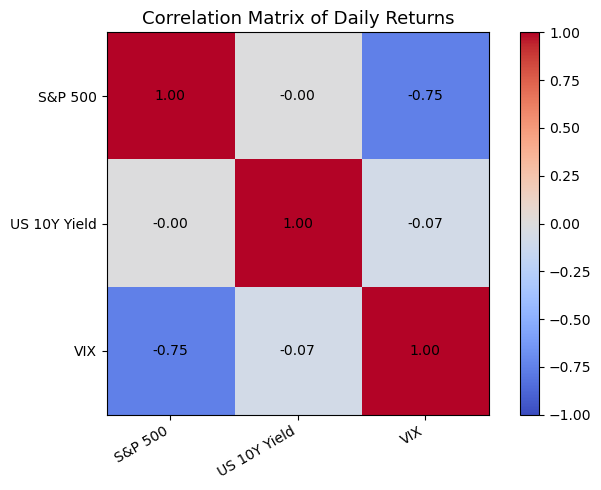

In [24]:
corr = returns.corr()

plt.figure(figsize=(7, 5))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=30, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix of Daily Returns", fontsize=13)

# Add correlation values inside the heatmap
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

The correlation matrix highlights the relationships between key market variables.

Equity returns tend to be negatively correlated with volatility, while interest rates reflect a different macroeconomic dynamic.

## Conclusion

This dashboard highlights the interaction between equity markets, volatility, and interest rates.

Key takeaways:
- equity markets and volatility typically move in opposite directions,
- volatility spikes signal periods of market stress,
- interest rates provide important macroeconomic context.

Such analysis is essential for monitoring market conditions
and supporting trading decisions.